In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import monk_common as mc
import nn_common as nnc
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import importlib
from functools import partial
import pandas as pd
from sklearn.metrics import classification_report
import copy
from sklearn.model_selection import KFold, StratifiedKFold

importlib.reload(nnc)

<module 'nn_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/monk/nn_common.py'>

<h3>Preparation</h3>
<hr/>

<h4>Hyperparameters and settings</h4>
<p>Default setting and hyper parameters for the NN run
<ul>
<li></li>
</ul>
</p>

In [3]:
default_loss_function = nn.BCEWithLogitsLoss()
default_learning_rate = 1e-3
default_weight_decay = 1e-4
default_batch_size = 10

#Epochs
default_epochs=300
# Early stopping
default_patience=-1

default_seed = 1
default_min_delta = 1e-4

# Custom Hyperparameters
default_momentum = 0.5
default_nesterov = True


<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interchangeability with PyTorch.
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [4]:
df_train, df_test = mc.load_set(1)
X_tr, y_tr = mc.split_and_prepare_dataset(df_train)
X_ts, y_ts = mc.split_and_prepare_dataset(df_test)
mc.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


<h4>NN Architecture</h4>
<p>Defining the neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [5]:
# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]


# Defining network architecture
# For simplicity we start with just one hidden layer with small nr of hidden unit
hidden_unit = 5
net = nn.Sequential(
    # 1st Hidden Layer
    nn.Linear(input_dimension, hidden_unit, bias=True), # <- NET
    nn.ReLU(), # <- Activation function
    #nn.Tanh(), # <- Activation function

    # Output layer
    # The output layer is kept linear in order to decouple
    # the network architecture from the choice of the loss function
    # and the prediction phase
    nn.Linear(hidden_unit, 1, bias=True) # <- NET
)

# Output function, must be changed according to the type of
# task and loss function
output_adapter = nnc.binary_bce_adapter(threshold=0.5)

# Model implementation
model_template = nnc.MLP(net, output_adapter)
# weights initialization (for didactic purposes)
model_template.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))

# The weight update algorithm
# optimizer_template = partial(
#     torch.optim.Adam,
#     lr = default_learning_rate,
#     weight_decay = 1e-4
# )

# optimizer_template = partial(
#     torch.optim.AdamW,
#     lr = default_learning_rate,
#     weight_decay = 1e-4
# )

optimizer_template = partial(
    torch.optim.SGD,
    lr = 0.5,
    #momentum = default_momentum,
    #nesterov = default_nesterov,
    #weight_decay = 1e-4
)

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=0.5, patience=10, threshold=1e-4
)

print(model_template)

MLP(
  (_net): Sequential(
    (0): Linear(in_features=17, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=1, bias=True)
  )
)


<h3>NN Run</h3>
<hr/>

<h4>Hold-out</h4>
<p>Training model and prediction according to hold-out strategy.</p>

<h5>Training</h5>
<p>Training the model.</p>

In [6]:
importlib.reload(nnc)

# Clone an untrained model and its optimizer
model_ho = copy.deepcopy(model_template)

hist_tr, hist_vl, hist_tr_acc, hist_vl_acc, hist_grad = nnc.train(
    model_ho, X_tr, y_tr, optimizer_template, default_loss_function,
    batch_size=10, epochs=default_epochs, min_delta=default_min_delta, patience=default_patience, seed=1,
    scheduler_template=scheduler_template
)

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 300
Train           | samples: 100
Validation      | samples: 24
Batch type      | mini-batch (10)
Loss algorithm  | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.5}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------


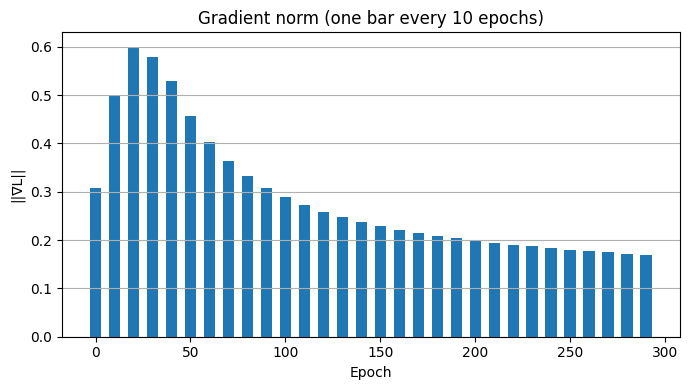

In [7]:
nnc.plot_gradient_norm_bars(hist_grad, step=10)

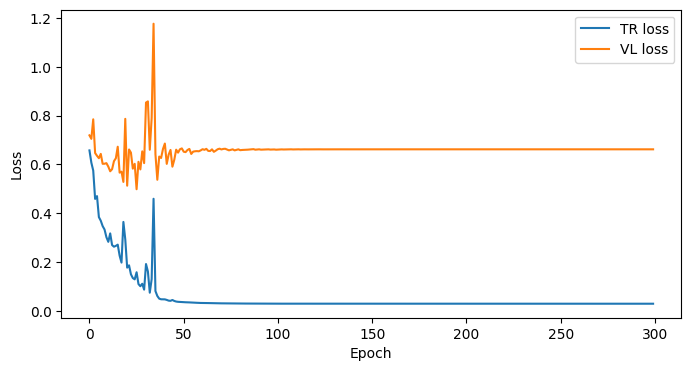

In [8]:
nnc.plot_epoch_loss(hist_tr, hist_vl)

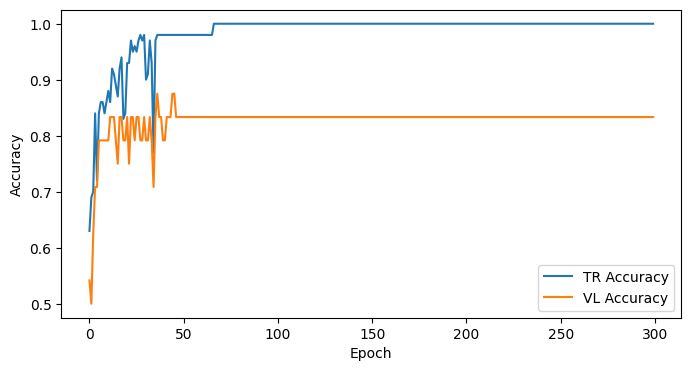

In [9]:
importlib.reload(nnc)
nnc.plot_epoch_accuracy(hist_tr_acc, hist_vl_acc)

<h5>Prediction</h5>
<p>Prediction with the official test set.</p>

In [10]:
importlib.reload(nnc)
all_pred = nnc.predict(model_ho, X_ts)

y_pred = pd.DataFrame(all_pred[0].detach().cpu().numpy())
print(classification_report(y_ts, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       216
           1       0.92      0.83      0.87       216

    accuracy                           0.88       432
   macro avg       0.88      0.88      0.88       432
weighted avg       0.88      0.88      0.88       432



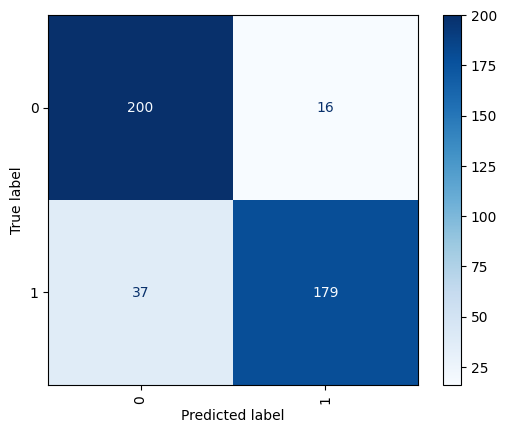

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_ts, y_pred, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h4>KFold</h4>
<p>Perform training and validation according to KFold strategy.</p>

<h5>Parameters</h5>
<p>The number of epoch has been increased in respect to hold-out validation, but early stopping have also been enabled to avoid overfitting.</p>
<p>The StratifiedKFold has been choosed for this particular small dataset as it keeps a balance between classes.</p>

In [12]:
importlib.reload(nnc)

#kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

inner_train_params = {
    "epochs": 1000, # Settings higher epochs than hold out along with early stopping
    "batch_size": 5,
    "patience": 100,
    "min_delta": default_min_delta,
    "seed": default_seed
}

fold_histories = nnc.run_kfold(
    model_template, X_tr, y_tr, optimizer_template, scheduler_template, default_loss_function, kf, inner_train_params
)


  
Perform fold: 0, train size: 99, val size: 25
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 80
Validation      | samples: 19
Batch type      | mini-batch (5)
Loss algorithm  | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.5}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | patience: 100 , minimum delta: 0.0001
----------------------------------------------------------------------------------------------------
Early stopping at epoch 141 (best VL loss: 0.1406)
  
Perform fold: 1, train size: 99, val size: 25
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 80
Validation      | samples: 19
Batch type      | mini-batch (5)
Loss algorithm  | BCEWi

In [13]:
importlib.reload(nnc)
summary = nnc.summarize_kfold_table(fold_histories, use="best")

K-Fold summary (BEST metrics)
------------------------------------------------------
Fold | best_vl_acc | best_vl_loss | gap_tr-vl(acc)
------------------------------------------------------
   1 |     0.9474 |    0.140646 |         0.0526
   2 |     0.7368 |    0.486541 |         0.1382
   3 |     0.8421 |    0.568618 |         0.0579
   4 |     0.8947 |    0.295602 |         0.0678
   5 |     1.0000 |    0.040736 |         0.0000
------------------------------------------------------
MEAN |     0.8842 |    0.306429
STD  |     0.0906 |    0.199688
------------------------------------------------------


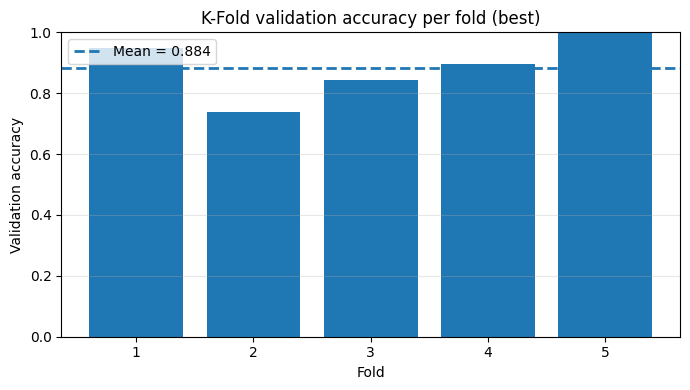

In [14]:
nnc.plot_kfold_bar_acc(fold_histories, use="best")

<h5>Prediction</h5>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on official test set.</p>

In [15]:
# dopo aver scelto best_params dal KFold
model_kf = copy.deepcopy(model_template)

hist_kf_tr, hist_kf_vl, hist_kf_tr_acc, hist_kf_vl_acc, hist_kf_grad = nnc.train(
    model_kf, X_tr, y_tr, optimizer_template, default_loss_function,
    epochs=inner_train_params['epochs'], batch_size=inner_train_params['batch_size'],scheduler_template=scheduler_template,
    seed=inner_train_params['seed'], patience=inner_train_params['patience'], min_delta=inner_train_params['min_delta'])

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 300
Train           | samples: 100
Validation      | samples: 24
Batch type      | mini-batch (10)
Loss algorithm  | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.5}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------


<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

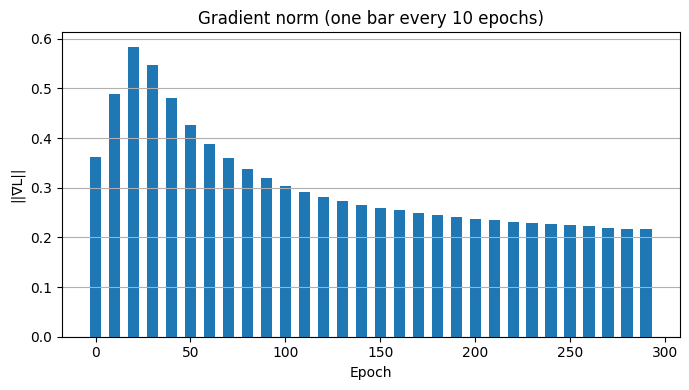

In [16]:
nnc.plot_gradient_norm_bars(hist_kf_grad, step=10)

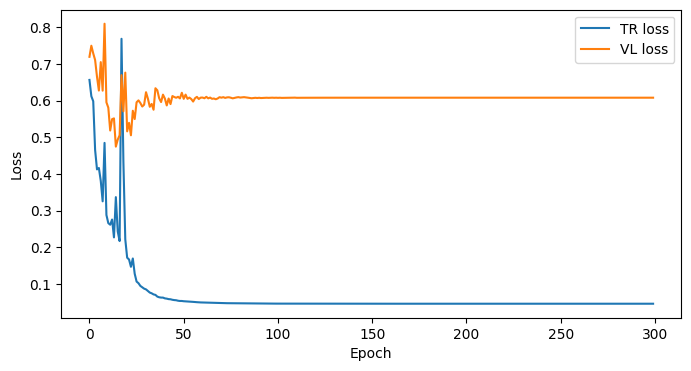

In [17]:
nnc.plot_epoch_loss(hist_kf_tr, hist_kf_vl)

In [18]:
all_kf_pred = nnc.predict(model_kf, X_ts)

y_kf_pred = pd.DataFrame(all_pred[0].detach().cpu().numpy())
print(classification_report(y_ts, y_kf_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       216
           1       0.92      0.83      0.87       216

    accuracy                           0.88       432
   macro avg       0.88      0.88      0.88       432
weighted avg       0.88      0.88      0.88       432



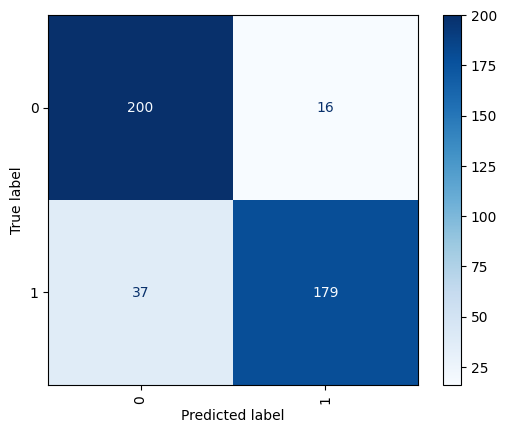

In [19]:
ConfusionMatrixDisplay.from_predictions(y_ts, y_kf_pred, xticks_rotation='vertical', cmap='Blues');